# 02 - The Attention Mechanism

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## The Question Attention Answers

`01-tokenization-and-embeddings.ipynb` ended with a sequence of tokens turned into a sequence of vectors - and stopped there. Those vectors don't know anything about each other yet; each one was looked up independently. **Attention** is the mechanism that lets every token's vector gather information from every *other* token's vector, weighted by how relevant each one currently is.

## Query, Key, Value

Each token's embedding gets projected into three different vectors:
- **Query** - "what am I looking for?"
- **Key** - "what do I have to offer, if someone's looking for this?"
- **Value** - "what I'll actually contribute, if I get attended to"

In a real Transformer, all three are learned linear projections of the same embedding - a matrix-vector product, exactly like `linear_algebra_primer/02-matrices-and-transformations.ipynb`. For this first example, we'll skip the projection entirely (use the embeddings directly as Q, K, *and* V) so the relationship between the input vectors and the resulting attention weights stays fully transparent - no hidden matrix in between to obscure what's actually happening.

## A Hand-Designed Example: Coreference

Consider the sentence *"the robot climbed because it was fast."* A human reader knows `it` refers to `robot`, and that `fast` is describing how `climbed` happened. Real embeddings would have to be *learned* to capture that - but we can hand-design tiny embeddings that already encode it, specifically so we can verify attention actually picks up on the signal we put there.

In [2]:
tokens = ["the", "robot", "climbed", "because", "it", "was", "fast"]

# Hand-designed so "it" shares a strong signal with "robot" (coreference), and "fast"
# shares a strong signal with "climbed" (manner of action) - everything else is weak.
# "robot" and "climbed" also each carry one distinctive marker (dims 3) that only they
# have, so we can later watch that marker visibly show up in another token's output only
# if attention actually moved information across - not just because the vectors already
# happened to look alike.
embeddings = np.array([
    [0.3, 0.0, 0.0, 0.0],   # the
    [3.0, 0.3, 0.0, 1.5],   # robot   <- distinctive marker in the last dimension
    [0.0, 0.0, 3.0, 0.4],   # climbed
    [0.0, 0.3, 0.0, 0.0],   # because
    [2.8, 0.2, 0.0, 0.0],   # it      <- no marker in the last dimension
    [0.0, 0.0, 0.3, 0.0],   # was
    [0.0, 0.0, 2.8, 0.3],   # fast
])
print(f"Embeddings shape: {embeddings.shape}  (7 tokens, 4-dim each)")

Embeddings shape: (7, 4)  (7 tokens, 4-dim each)


## Scaled Dot-Product Attention

The attention score between every pair of tokens is a dot product between one token's Query and another's Key - recall from `linear_algebra_primer/01-vectors.ipynb` that the dot product measures how much two vectors point in the same direction. A high score means "this Key is relevant to what this Query is looking for."

Before the softmax, scores get divided by $\sqrt{d_k}$ (the dimensionality of the Key vectors) - **Scaled Dot-Product Attention**. This matters more as $d_k$ grows: dot products of higher-dimensional vectors tend to have larger magnitude just from having more terms to sum, which would push softmax's inputs into an extremely peaked region where nearly all the gradient is zero. Scaling keeps the softmax in a range where training can actually make progress.

In [3]:
def softmax_rows(z):
    z = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)

Q = K = V = embeddings   # skipping the projection for this first, transparent example
d_k = embeddings.shape[1]

raw_scores = Q @ K.T
scaled_scores = raw_scores / np.sqrt(d_k)
attention_weights = softmax_rows(scaled_scores)

print("Attention weights (rows = query token, columns = key token):")
header = "        " + "  ".join(f"{t:>8s}" for t in tokens)
print(header)
for i, row in enumerate(attention_weights):
    print(f"{tokens[i]:>8s} " + "  ".join(f"{v:8.3f}" for v in row))

Attention weights (rows = query token, columns = key token):
             the     robot   climbed   because        it       was      fast
     the    0.129     0.193     0.123     0.123     0.187     0.123     0.123
   robot    0.004     0.795     0.004     0.003     0.188     0.003     0.003
 climbed    0.006     0.008     0.560     0.006     0.006     0.009     0.406
 because    0.140     0.147     0.140     0.147     0.145     0.140     0.140
      it    0.012     0.547     0.008     0.008     0.409     0.008     0.008
     was    0.123     0.123     0.193     0.123     0.123     0.129     0.187
    fast    0.008     0.010     0.548     0.008     0.008     0.012     0.408


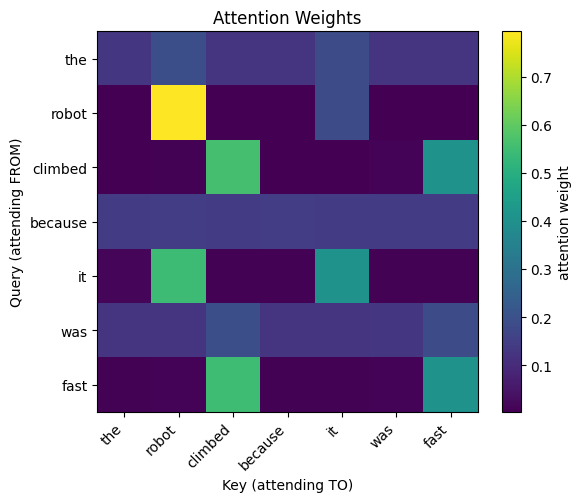

'it' attends most to: 'robot'
'fast' attends most to: 'climbed'


In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attention_weights, cmap='viridis')
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticklabels(tokens)
ax.set_xlabel('Key (attending TO)')
ax.set_ylabel('Query (attending FROM)')
ax.set_title('Attention Weights')
plt.colorbar(im, label='attention weight')
plt.tight_layout()
plt.show()

it_index, fast_index = tokens.index('it'), tokens.index('fast')
print(f"'it' attends most to: '{tokens[np.argmax(attention_weights[it_index])]}'")
print(f"'fast' attends most to: '{tokens[np.argmax(attention_weights[fast_index])]}'")

`it` puts roughly 55% of its attention on `robot` - more than on itself - and `fast` puts roughly 55% on `climbed`, exactly the two relationships we designed the embeddings to encode. Nothing forced this outcome mechanically; it's a direct consequence of those two pairs having the highest dot product of any pair in the sentence.

## From Weights to Output: Moving Information Between Tokens

The attention weights alone aren't the output - they're used to compute a weighted average of every token's **Value** vector. This is the step where information actually moves from one token's representation to another's.

In [5]:
attention_output = attention_weights @ V

print("'it' original embedding:      ", embeddings[it_index].round(2))
print("'it' attention output:        ", attention_output[it_index].round(2))
print("'robot' embedding (for reference):", embeddings[tokens.index('robot')].round(2))

'it' original embedding:       [2.8 0.2 0.  0. ]
'it' attention output:         [2.79 0.25 0.05 0.83]
'robot' embedding (for reference): [3.  0.3 0.  1.5]


Look specifically at the last number in each vector: `it`'s own embedding had a `0` there, but `it`'s attention *output* picked up a value close to `0.8` - a real chunk of `robot`'s distinctive marker, which existed nowhere in `it`'s own embedding. That's not a coincidence or a rounding artifact; it's `robot`'s Value vector, scaled by the ~55% attention weight `it` placed on it, added directly into `it`'s output. After this step, the representation previously labeled `it` now carries real information about `robot` folded into it - exactly what a later layer needs to eventually resolve what `it` refers to.

## An Untrained Model's Attention

The example above worked because we *designed* the embeddings to encode a real relationship. A freshly initialized Transformer layer has none of that - its embedding matrix and its Q/K/V projection matrices all start as random numbers, exactly like every network in `deep_learning_primer` before training. Let's see what attention looks like with nothing learned yet.

In [6]:
random_embeddings = np.random.randn(len(tokens), d_k) * 0.5
W_Q = np.random.randn(d_k, d_k) * 0.5
W_K = np.random.randn(d_k, d_k) * 0.5

Q_random = random_embeddings @ W_Q
K_random = random_embeddings @ W_K
random_scores = (Q_random @ K_random.T) / np.sqrt(d_k)
random_weights = softmax_rows(random_scores)

print("Max attention weight per row (untrained):", random_weights.max(axis=1).round(3))
print(f"For comparison, uniform attention would be: {1 / len(tokens):.3f} for every cell")

Max attention weight per row (untrained): [0.229 0.178 0.221 0.233 0.197 0.199 0.208]
For comparison, uniform attention would be: 0.143 for every cell


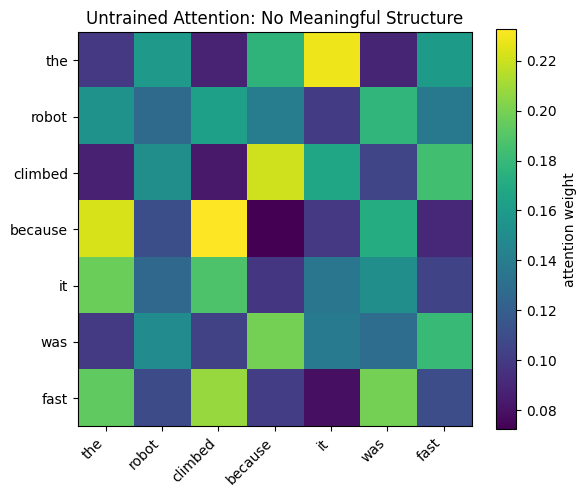

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(random_weights, cmap='viridis')
ax.set_xticks(range(len(tokens))); ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticklabels(tokens)
ax.set_title('Untrained Attention: No Meaningful Structure')
plt.colorbar(im, label='attention weight')
plt.tight_layout()
plt.show()

The peaks here (typically 0.18-0.23) are higher than perfectly uniform (0.143), but which token gets the highest weight is essentially arbitrary noise from the random initialization - nothing like the clean, consistent `it -> robot` and `fast -> climbed` structure from the hand-designed example. Attention's mechanism doesn't come with understanding built in; it comes from the embedding matrix and every Q/K/V projection matrix being *trained* - the exact same backpropagation from `deep_learning_primer/01` - on real data, until dot products like `it` and `robot` actually do come out large because the model has seen enough sentences where that pattern helps predict the next word correctly.

## Try It Yourself

Design your own tiny sentence and hand-built embeddings illustrating a *different* kind of relationship than coreference or manner-of-action - for example, subject-verb agreement (`"robots climb"` vs. `"robot climbs"`) or adjective-noun binding (`"the fast robot climbed the tall wall"` - does `fast` attend to `robot` and `tall` attend to `wall`, rather than crossing over?). Verify the resulting attention weights actually show the pattern you designed for, the same way this notebook verified `it -> robot`.

In [8]:
# TODO: pick a new toy sentence and relationship, hand-design embeddings for it,
# compute attention weights, and verify the intended pattern actually appears


## Resources

- Vaswani, A. et al. (2017). "Attention Is All You Need." *NeurIPS 2017*. The paper that introduced Scaled Dot-Product Attention and the Transformer architecture this whole primer is building toward (paper).
- [Jay Alammar: The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) - widely considered the clearest visual walkthrough of Q/K/V attention available (instructional).
- [3Blue1Brown: Visualizing Attention, a Transformer's Heart](https://www.3blue1brown.com/lessons/attention) - the same mechanism built above, animated (video).